[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/choROPeNt/FFTjax/blob/main/notebooks/pff-damage.ipynb)

# Phase-Field Fracture on a CFRP Microstructure

A walkthrough of FFTjax's staggered phase-field fracture solver
(`problems.fracture.solve_fracture`) on a **randomly-periodic-packed circular carbon-fibre composite** with three phases (matrix, interphase, fiber) -- generated with `generation.rve.make_random_composite_rve` ([Catalanotti 2016](https://doi.org/10.1016/j.compstruct.2015.11.039)).

Two coupled PDEs are solved, staggered: mechanical equilibrium with a damage-degraded stiffness,

$$
\nabla \cdot \sigma(\mathbf{x}) = 0, \qquad
\sigma = g(d)\,\mathbb{C}(\mathbf{x}):\varepsilon, \qquad
\varepsilon = \tfrac12\big(\nabla u + \nabla u^\top\big),
$$

and the AT2 damage evolution equation -- stationarity of the regularized fracture energy

$$\Pi = \int_\Omega \big[g(d)\psi^+ + \psi^-\big]\,dV + G_c\!\int_\Omega\!\big[\tfrac{d^2}{2\ell_0} + \tfrac{\ell_0}{2}|\nabla d|^2\big]\,dV$$

with respect to $d$:

$$
\frac{G_c}{\ell_0}\,d \;-\; G_c\,\ell_0\,\Delta d \;=\; -g'(d)\,H, \qquad d \ge d_{\text{prev}} \ \text{(irreversibility)}.
$$

Here $g(d) = (1-k_{res})(1-d)^2 + k_{res}$ is the AT2 degradation function ($k_{res}$ a residual
stiffness keeping $d=1$ from going exactly singular), $\psi^+$ is the tensile part of the elastic
strain energy density
([Amor, Marigo & Maurini 2009](https://doi.org/10.1016/j.jmps.2009.04.011) volumetric-deviatoric
split), and $H$ is a history variable enforcing irreversibility -- here via the *hybrid* scheme
([Steinke & Kaliske 2019](https://doi.org/10.1007/s00466-018-1635-0), as adopted by
[Schneider & Kästner 2025](https://doi.org/10.1111/ffe.14553)) rather than the classical
$H=\max_{s\le t}\psi^+(s)$, which over-widens the diffuse process zone. Each staggered iteration
freezes $d$ and solves for $u$ (hence $\varepsilon,\sigma,\psi^+$), then freezes $u$ and solves for
$d$, repeating until $d$ stops changing. Full derivation:
[Damage & Fracture Solvers](https://choROPeNt.github.io/FFTjax/documentation/theorie/damage) in
the documentation.

Material constants and phase-field parameters below are the same ones already used in
`configs/user/pff_prototype.yaml`, the project's reference config for the real-patch dataset -- see
that file for the full production setup (adaptive timestepper, YAML-driven, XDMF output). This
notebook strips that down to a minimal, directly-runnable walkthrough on a synthetic RVE instead,
so it needs no external data file.

## Setup

In [1]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Running on Colab — installing FFTjax...")
    %pip install -q git+https://github.com/choROPeNt/FFTjax.git
else:
    import sys
    sys.path.insert(0, "../src")
    print("Running locally — using the local src/ checkout.")

import os
import utils.precision  # side effect: configures JAX (X64 off on TPU, no GPU prealloc)
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

print("JAX backend:", jax.default_backend())
print("Devices:", jax.devices())
print("X64 enabled:", utils.precision.X64_ENABLED,
      "-> dtype:", jnp.zeros(1).dtype)

Running locally — using the local src/ checkout.


JAX backend: cpu
Devices: [CpuDevice(id=0)]


X64 enabled: True -> dtype: float64


## Generate a random-fibre RVE

Generates an idealized microstructure with `generation.rve.make_random_composite_rve`
(Catalanotti 2016) -- randomly-packed circular fibres with a thin interphase ring around each one,
same generator driving `scripts/generation/generate_rve.py`/`configs/generation/rve_random.yaml`.

The generator's own phase labeling is `0=matrix, 1=fibre, 2=interphase`; remapped below to
`0=matrix, 1=interphase, 2=fibre` to match this notebook's materials list (`[matrix, interphase,
fiber]`). Every fibre shares one global orientation (along Z).

In [2]:
from generation.rve import make_random_composite_rve

phi_target = 0.55           # target fibre volume fraction
r_fiber    = 0.0035         # fibre radius [mm]
vox        = 0.0001         # target voxel size [mm]
interphase_thickness = 0.0002   # mm

phase_raw, n, L, phi_fiber_act, centres = make_random_composite_rve(
    phi=phi_target,
    r_fiber=r_fiber,
    dx=vox,
    size_in_r=15,   # domain side ~ 15*r_fiber (Catalanotti 2016 convention)
    nz=1,
    K=15,           # perturbation iterations (K>10 -> fully randomised)
    seed=67,
    interphase_thickness=interphase_thickness,
)

# remap 0=matrix,1=fibre,2=interphase (generator's own labeling) -> 0=matrix,
# 1=interphase,2=fibre (this notebook's convention, see markdown above)
phase_np = np.where(phase_raw == 1, 2, np.where(phase_raw == 2, 1, 0)).astype(np.uint8).reshape(-1)

Nv = int(np.prod(n))
dx = tuple(Li / ni for Li, ni in zip(L, n))

# idealized RVE: every fibre shares one global axis (along Z), unlike a real
# patch's per-voxel orientation field
fibre_dir = np.array([0.0, 0.0, 1.0])
orientation_np = np.tile(fibre_dir[:, None], (1, Nv))   # (3, Nv)

phi = float((phase_np == 2).mean())  # fibre+interphase volume fraction

print("Generated random-fibre RVE (Catalanotti 2016)")
print("grid n :", n)
print("domain L [mm]:", L)
print("phi (fibre+interphase volume fraction):", phi)
print("phase fractions -- matrix:", float((phase_np == 0).mean()),
      " interphase:", float((phase_np == 1).mean()),
      " fibre:", float((phase_np == 2).mean()))

Generated random-fibre RVE (Catalanotti 2016)
grid n : (630, 623, 1)
domain L [mm]: (np.float64(0.06292081801414708), np.float64(0.062275459231027314), 0.0001)
phi (fibre+interphase volume fraction): 0.5500114652602615
phase fractions -- matrix: 0.3881958776019771  interphase: 0.06179265713776147  fibre: 0.5500114652602615


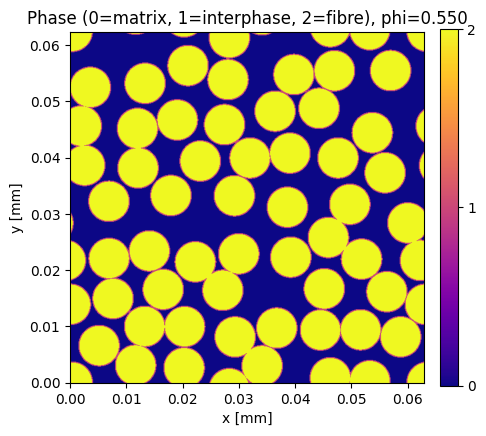

In [3]:
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(phase_np.reshape(n)[:, :, 0].T, origin="lower", cmap="plasma",
               extent=[0, n[0]*dx[0], 0, n[1]*dx[1]])
ax.set_title(f"Phase (0=matrix, 1=interphase, 2=fibre), phi={phi:.3f}")
ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")
# fraction/pad match the colorbar height to the square imshow panel -- without
# them, fig.colorbar sizes to the axes' unshrunk bounding box, not the square
# image imshow actually renders inside it, so it comes out much taller.
fig.colorbar(im, ax=ax, ticks=[0, 1, 2], fraction=0.046, pad=0.04)
plt.show()

## Materials and stiffness field

Same constants as `configs/user/pff_prototype.yaml`: an epoxy matrix, an interphase layer (the
config's placeholder modulus -- between the matrix and the fibre's transverse modulus, since
there's no real scan to calibrate it against for this synthetic RVE), and a transversely isotropic
carbon fibre using typical literature constants.

`assemble_C_field` builds the per-voxel stiffness field by phase index. It doesn't rotate per-voxel
fibre orientation yet (the new layout has no equivalent of the old `assemble_C_field_oriented`) --
not needed here regardless, since every fibre in this RVE already shares `TransverseIsotropic`'s
reference axis (Z, see the RVE-generation cell above), so there's nothing to rotate.

In [4]:
from materialmodels.elastic.isotropic import LinearElasticIsotropic
from materialmodels.elastic.transversely_isotropic import TransverseIsotropic
from materialmodels.assembly import assemble_C_field, describe_materials
from materialmodels.phasefield.driving_force import lame_field

# Gc set per-material so solve_fracture can gather the heterogeneous Gc field
# automatically (Gc=None below); fiber's k_res=1.0 makes it damage-immune --
# the new-layout equivalent of the old manual damage_zone masking.
matrix = LinearElasticIsotropic(E=3500.0, nu=0.35, Gc=0.8e-3, name="epoxy matrix")
interphase = LinearElasticIsotropic(E=12000.0, nu=0.35, Gc=0.4e-3, name="interphase")
fiber = TransverseIsotropic(
    E_L=230000.0, E_T=15000.0, G_LT=15000.0, nu_LT=0.20, nu_TT=0.30,
    k_res=1.0, Gc=1.6e-3, name="carbon fibre",
)
materials = [matrix, interphase, fiber]

phase = jnp.array(phase_np)
orientation = jnp.array(orientation_np)
matrix_mask = phase == 0
interphase_mask = phase == 1
fiber_mask = phase == 2
damage_zone = matrix_mask | interphase_mask   # fibre never damages

C_field = assemble_C_field(materials, phase)
lam_vox, mu_vox = lame_field(materials, phase)

describe_materials(materials)

phase 0: LinearElasticIsotropic (epoxy matrix): E=3.5e+03, nu=0.35, lam=3.02e+03, mu=1.3e+03
phase 1: LinearElasticIsotropic (interphase): E=1.2e+04, nu=0.35, lam=1.04e+04, mu=4.44e+03
phase 2: TransverseIsotropic (carbon fibre): E_L=2.3e+05  E_T=1.5e+04  G_LT=1.5e+04  G_TT=5.77e+03  nu_LT=0.2  nu_TT=0.3


## Fracture Solve

Uniaxial tension along x, ramped up over 30 equal load-fraction increments via
`problems.fracture.solve_fracture_incremental(..., stepping="fixed")` -- the same incremental
wrapper `solve_mechanics` uses, here driving `solve_fracture`'s staggered mechanics<->damage solve
(AT2 degradation, Amor split, hybrid irreversibility, all internal) once per increment instead of
a hand-rolled Python loop.

In [5]:
from typing import cast

from problems.fracture import FractureSolution, solve_fracture_incremental

TOLER_LIN = 1e-2
TOLER_HELM = 1e-2
MAXITER_CG = 200
MAXITER_HELM = 200
MAXITER_STAGGER = 30
TOLER_ST_ABS = 1e-2

EPS_MAX = 0.2e-2   # target macroscopic strain at t=1

l0 = 3.0 * dx[0]   # length scale, a few voxels wide
eps_dir = jnp.array([[1.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0]])
eps_bar_target = EPS_MAX * eps_dir

def _report(r, write_time):
    sol = cast(FractureSolution, r.solution)
    print(f"step {r.step:3d}  t={r.t:.3f}  eps11={r.t * EPS_MAX:.2e}  "
          f"sigma11_ave={float(jnp.mean(sol.sigma[0, 0])):8.3f} MPa  "
          f"max(d)={float(jnp.max(sol.d)):.4f}  staggered_iters={sol.iter_staggered}")

results = solve_fracture_incremental(
    n, L, phase, materials, eps_bar_target, l0, None, jnp.zeros(Nv), jnp.zeros(Nv),
    stepping="fixed", dt_step=0.01,
    toler_lin=TOLER_LIN, maxiter_cg=MAXITER_CG,
    toler_helm=TOLER_HELM, maxiter_helm=MAXITER_HELM,
    toler_st_abs=TOLER_ST_ABS, maxiter_st=MAXITER_STAGGER,
    on_increment=_report,
)

sol = cast(FractureSolution, results[-1].solution)
eps, sigma, d_field = sol.eps, sol.sigma, sol.d
print("\nPASSED -- mechanical CG converged at every accepted increment.")

step   1  t=0.010  eps11=2.00e-05  sigma11_ave=   0.203 MPa  max(d)=0.0000  staggered_iters=1


step   2  t=0.020  eps11=4.00e-05  sigma11_ave=   0.407 MPa  max(d)=0.0000  staggered_iters=1


step   3  t=0.030  eps11=6.00e-05  sigma11_ave=   0.610 MPa  max(d)=0.0001  staggered_iters=1


step   4  t=0.040  eps11=8.00e-05  sigma11_ave=   0.814 MPa  max(d)=0.0001  staggered_iters=1


step   5  t=0.050  eps11=1.00e-04  sigma11_ave=   1.017 MPa  max(d)=0.0001  staggered_iters=1


...

step  96  t=0.960  eps11=1.92e-03  sigma11_ave=  19.084 MPa  max(d)=0.0624  staggered_iters=1


step  97  t=0.970  eps11=1.94e-03  sigma11_ave=  19.273 MPa  max(d)=0.0639  staggered_iters=1


step  98  t=0.980  eps11=1.96e-03  sigma11_ave=  19.462 MPa  max(d)=0.0655  staggered_iters=1


step  99  t=0.990  eps11=1.98e-03  sigma11_ave=  19.650 MPa  max(d)=0.0670  staggered_iters=1


step 100  t=1.000  eps11=2.00e-03  sigma11_ave=  19.838 MPa  max(d)=0.0686  staggered_iters=1

PASSED -- mechanical CG converged at every accepted increment.


## Visualize: macroscopic response and damage field

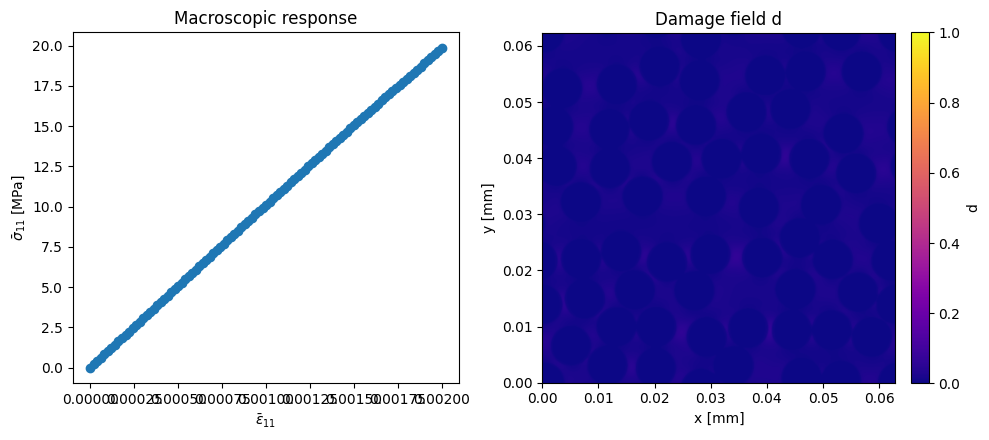

In [6]:
from post.fields import homogenize_response
from utils.plotting import FieldPanel, ResponseCurve, imshow_panel, plot_homogenized_response

eps11, sigma11 = homogenize_response(results, component=(0, 0))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

plot_homogenized_response(
    [ResponseCurve(eps11, sigma11)], ax=axes[0],
    xlabel=r"$\bar\varepsilon_{11}$", ylabel=r"$\bar\sigma_{11}$ [MPa]",
)

d_grid = np.asarray(d_field).reshape(n)
imshow_panel(axes[1], FieldPanel(d_grid[:, :, 0], "Damage field d", vmin=0, vmax=1, cbar_label="d"),
             extent=[0, n[0]*dx[0], 0, n[1]*dx[1]])

fig.tight_layout()
plt.show()

## Post-processing: export to XDMF/HDF5

Same field-writing convention as the rest of the project (`post.io.IncrementalWriter`), so the
result can be opened in ParaView (`Xdmf3ReaderT`) alongside the other examples' output.

In [ ]:
from post.fields import field_to_grid, von_mises, to_voigt
from utils.io.xdmf_writer import IncrementalWriter

eps_grid = field_to_grid(eps, n)
sigma_grid = field_to_grid(sigma, n)
vm_grid = von_mises(sigma_grid)

output_dir = "output" if IN_COLAB else "../output/notebooks" 

import os
os.makedirs(output_dir, exist_ok=True)

with IncrementalWriter(f"{output_dir}/pff_damage_patch", grid_shape=n, grid_length=L) as w:
    w.write_increment(0, {
        "phase":     phase_np.astype(np.float64).reshape(n),
        "strain":    to_voigt(eps_grid).astype(np.float64),
        "stress":    to_voigt(sigma_grid).astype(np.float64),
        "von_mises": vm_grid.astype(np.float64),
        "damage":    d_grid.astype(np.float64),
    }, time=0.0)

print(f"Wrote {output_dir}/pff_damage_patch.h5")
print(f"      {output_dir}/pff_damage_patch.xdmf")
print("Open the .xdmf in ParaView with the 'Xdmf3ReaderT' reader.")

Wrote ../output/pff_damage_patch.h5
      ../output/pff_damage_patch.xdmf
Open the .xdmf in ParaView with the 'Xdmf3ReaderT' reader.


## Next steps

- Try a different `seed`/`phi_target` in the RVE generation cell above -- fibre packing and volume
  fraction both shift damage nucleation sites and the macroscopic response, same as switching
  between real patches from `data/patches_fft/` would (see `configs/user/pff_prototype.yaml`).
- Compare against the idealized sphere-seed example in `examples/pff_damage.py` --
  real, sharp-interface microstructure typically shows more localized, geometry-driven
  damage nucleation than an idealized seed does.
- See `configs/user/pff_prototype.yaml` for the full production setup with an adaptive timestepper,
  driven via `scripts/simulation/pff_nw_cg_strain.py`.